# The stress tensor

The stress says how the total energy responds to deforming the cell, and it is what tells a
calculation whether a crystal is at its equilibrium lattice constant, under pressure, or
unstable:

$$\mathbf a_i \;\to\; (\delta_{ab} + \epsilon_{ab})\,\mathbf a_i,
\qquad
\sigma_{ab} = -\frac{1}{\Omega}
  \left.\frac{\partial E_{\rm tot}}{\partial \epsilon_{ab}}\right|_{\psi\ \rm fixed},
\qquad
P = \tfrac{1}{3}\,\mathrm{tr}\,\sigma$$

Like the force, it is a derivative of the total energy itself rather than an expression
derived by hand for it, taken at frozen wavefunctions -- legitimate because the energy is
stationary in them, with the cell taking the place of the atoms. On five silicon references,
each adding one thing to the one before:

| | pressure, pypresso | `pw.x` |
|---|---|---|
| norm-conserving, one atom displaced | **-23.58 kbar** | -23.58 |
| the same cell sheared by 4% | **-31.13 kbar** | -31.13 |
| ultrasoft | **+10.53 kbar** | 10.53 |
| PAW | **+10.95 kbar** | 10.95 |
| ultrasoft, PBE | **+47.08 kbar** | 47.08 |

Every entry of the tensor agrees to **2.7e-7 Ry/bohr³ or better**, and so does each of the
contributions `pw.x` prints separately -- 4.0e-8 on the sheared cell, which is 0.006 kbar
against a printed resolution of 0.01.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import comparison_table, read_qe_output
from pypresso.units import RY_TO_KBAR

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

sheared = Calculator.from_file(CASES / "si2-nc-sheared.in", pseudo_dir=PSEUDO,
                               announce=False)
stress = sheared.get_stress(terms=True)
print("sigma [kbar]\n%s\n\npressure   %.2f kbar"
      % (np.round(stress.tensor * RY_TO_KBAR, 3), stress.pressure_kbar))

sigma [kbar]
[[-74.326  -1.258 -19.214]
 [ -1.258   3.691 -21.689]
 [-19.214 -21.689 -22.765]]

pressure   -31.13 kbar


`si2-nc-sheared.in` is the two-atom silicon cell with $\mathbf a_3$ tilted by 4% in the *xy*
plane. The tilt is deliberate: on the ideal cubic cell the stress is a multiple of the
identity, and a tensor with the wrong shear components would look perfect. Here the crystal
keeps two symmetry operations and every entry of $\sigma$ is free to be wrong.

Because it is one expression that is differentiated, the decomposition into kinetic,
Hartree, local, exchange-correlation, nonlocal and Ewald pieces comes out of the same
derivative, with no expression written separately for any of them:

In [2]:
qe = read_qe_output(CASES / "reference.out.si2-nc-sheared")

print("%10s %s" % ("", "   ".join("%9s" % ax for ax in "xx yy zz".split())))
for name, tensor in sorted(stress.terms.items()):
    if np.abs(tensor).max() > 1e-12:
        print("%10s %s" % (name, "   ".join("%9.2f" % (v * RY_TO_KBAR)
                                            for v in np.diag(tensor))))
worst = max(np.abs(stress.terms[name] - np.asarray(theirs)).max()
            for name, theirs in qe.stress_terms.items() if name in stress.terms)
print("\nworst per-term disagreement with pw.x   %.1e Ry/bohr^3   (%.3f kbar, "
      "which is how finely pw.x prints them)" % (worst, worst * RY_TO_KBAR))

                  xx          yy          zz
     ewald  -2965.97    -3292.10    -3124.54
   hartree    225.90      168.00      201.72
   kinetic   2216.41     2308.48     2278.52
     local  -1594.37    -1198.47    -1410.62
  nonlocal   2854.30     2828.38     2842.76
        xc   -810.60     -810.60     -810.60

worst per-term disagreement with pw.x   4.0e-08 Ry/bohr^3   (0.006 kbar, which is how finely pw.x prints them)


## The pressure is a thermodynamic derivative, and nothing above knows that

$\sigma$ came from a derivative taken at **one** volume with the wavefunctions frozen. The
pressure is $P = -dE/dV$, a derivative of the energy across *separate* calculations. Computing
`E(V)` by re-converging at a series of lattice constants and differentiating the curve is
therefore an independent check, and the one that says the strain gradient is the derivative
of the energy the self-consistent loop actually minimises.

The cutoff matters here and nowhere else in this notebook. Expanding the cell at fixed
`ecutwfc` lets *more* plane waves inside the sphere, so the basis improves as the volume
grows and the energy falls for a reason that is not physics. That artefact is the **Pulay
stress**: measured as a tight two-point difference it is about 44 kbar at `ecutwfc = 12`,
1.1 kbar at 40 and 0.11 at 60. The curve below is at 40, and any published pressure is only
as good as that number.

In [3]:
ideal = Calculator.from_file(CASES / "si2-nc-eos.in", pseudo_dir=PSEUDO, announce=False)
at = np.asarray(ideal.system.cell.at)

volumes, energies, pressures = [], [], []
for scale in np.linspace(0.96, 1.04, 7):
    step = ideal.with_cell(at * scale)
    volumes.append(float(step.system.cell.volume))
    energies.append(step.get_scf().total_energy)
    pressures.append(step.get_stress().pressure_kbar)

volumes, energies = np.array(volumes), np.array(energies)
pressures, numerical = np.array(pressures), -np.gradient(energies, volumes) * RY_TO_KBAR
print("max |tr sigma/3 + dE/dV| over the interior points   %.2f kbar,  against a pressure "
      "spanning %.0f to %.0f" % (np.abs(pressures - numerical)[1:-1].max(),
                                 pressures.min(), pressures.max()))

max |tr sigma/3 + dE/dV| over the interior points   2.58 kbar,  against a pressure spanning -83 to 161


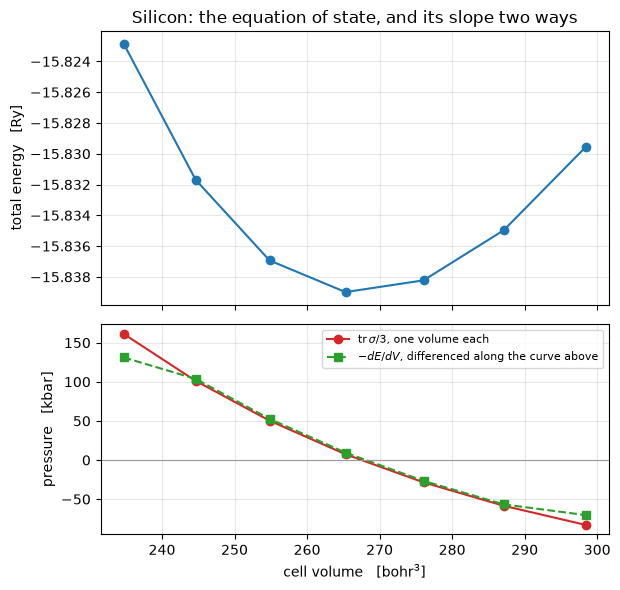

In [4]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(6.4, 6.0), sharex=True,
                                  gridspec_kw={"height_ratios": [1.3, 1]})
top.plot(volumes, energies, "o-", color="#1f77b4")
top.set_ylabel("total energy   [Ry]")
top.set_title("Silicon: the equation of state, and its slope two ways")
top.grid(alpha=0.3)

bottom.plot(volumes, pressures, "o-", color="#d62728",
            label=r"$\mathrm{tr}\,\sigma/3$, one volume each")
bottom.plot(volumes, numerical, "s--", color="#2ca02c",
            label=r"$-dE/dV$, differenced along the curve above")
bottom.axhline(0.0, color="0.6", lw=0.8)
bottom.set_xlabel(r"cell volume   [bohr$^3$]")
bottom.set_ylabel("pressure   [kbar]")
bottom.legend(fontsize=8)
bottom.grid(alpha=0.3)
fig.tight_layout()

Two curves computed in ways that share nothing: one a derivative at a single volume, the
other a derivative of a sequence of separate self-consistent calculations, agreeing to 2.6
kbar on a pressure that spans 244. That residue is the Pulay stress plus the truncation error
of a seven-point central difference, which is why the tighter two-point number quoted above
is the smaller one. The volume where the red curve crosses zero is LDA silicon's equilibrium,
and relaxing the cell down to it is what notebook 23 does.

## Against Quantum ESPRESSO

In [5]:
rows = []
for case in ("si2-nc-stress", "si2-nc-sheared", "si2-us-stress",
             "si2-paw-stress", "si2-us-pbe-stress"):
    ours = Calculator.from_file(CASES / f"{case}.in", pseudo_dir=PSEUDO,
                                announce=False).get_stress()
    rows.append((case, ours.pressure_kbar,
                 read_qe_output(CASES / f"reference.out.{case}").pressure))

print(comparison_table(rows, fmt="{:.2f}",
                       headers=("case", "P here [kbar]", "pw.x", "difference")))

case               P here [kbar]    pw.x  difference
si2-nc-stress             -23.58  -23.58     3.4e-03
si2-nc-sheared            -31.13  -31.13     3.8e-03
si2-us-stress              10.53   10.53     3.6e-03
si2-paw-stress             10.95   10.95     4.2e-04
si2-us-pbe-stress          47.08   47.08     5.7e-04


Norm-conserving, sheared, ultrasoft, PAW and PBE: the last three each add a contribution the
first two do not have, and the augmentation charge's own response to a strain is the one that
is easiest to get wrong, because it changes the *table* $Q_{ij}(\mathbf r)$ rather than
translating it.

One subtlety makes the frozen-state derivative the right one. What is held fixed is the
*coefficient vector*: a strain carries the plane waves along with the cell, so freezing the
coefficients freezes the state in crystal coordinates, which is exactly the variational
parameter the self-consistent loop minimised over.

## What it refuses

QE's own expressions are transcribed beside the derivative as a cross-check, and **that route
is incomplete on purpose**: the ultrasoft augmentation terms are not among them, so it offers
a breakdown and no total for such a dataset, and it has no **spinor** form at all. The
differentiated route does have one, and a noncollinear stress is **opt-in** rather than
merely allowed, because the same functional is what the elastic constants and the
electrostriction reach directly and those have no spinor form above the linear solve. A
potential-only **meta-GGA** has no stress at all here, and that is a statement about the
functional rather than about the code: its total energy is not the value of anything that was
minimised, so a derivative of it means nothing.

---
The tests behind this notebook: `tests/regression/test_stress.py`, which holds the five
references, the term-by-term breakdown against QE's own, the pressure against a finite
difference of the energy, the rotational residue, and the noncollinear refusal; and
`tests/unit/test_stress_machinery.py`.